## Checking of Energy Minimization

In [1]:
import os
data_dir = "/home/daneel/gitrepos"
data_dir = os.path.join(data_dir, "gromacs_sims/Antimicrobial_Peptides/Ku04AMP01_Membrane_Bilayer/simulations_cg")
os.chdir(data_dir)


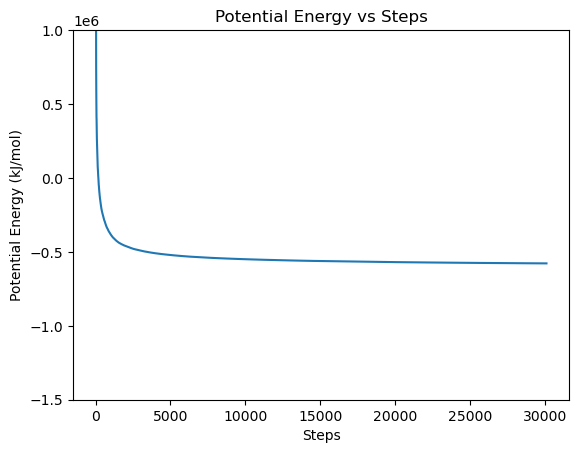

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load data, skipping lines starting with '@' and '#'
# unpack=True allows you to assign columns directly to x and y
x, y = np.loadtxt("simulation_cg_multipeptide/potential.xvg", comments=["@", "#"], unpack=True)

plt.plot(x, y)
plt.title("Potential Energy vs Steps")
plt.xlabel("Steps")
plt.ylabel("Potential Energy (kJ/mol)")
plt.ylim(-1500000, 1000000)  # Set y-axis limits for better visualization
plt.show()

In [3]:
import os 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import MDAnalysis as mda 
from MDAnalysis.analysis import rms 
from multiprocessing import Pool, cpu_count 
from functools import partial 
from tqdm.notebook import tqdm

In [4]:
complexes = {'multipeptide': {"top_file": "simulation_cg_multipeptide/traj_dry.tpr", "traj_file": "simulation_cg_multipeptide/traj_dry.xtc"},
            'nopeptide': {"top_file": "simulation_cg_nopeptide/traj_dry.tpr", "traj_file": "simulation_cg_nopeptide/traj_dry.xtc"},
            'single_peptide': {"top_file": "simulation_cg_trans_2.4nm/traj_dry.tpr", "traj_file": "simulation_cg_trans_2.4nm/traj_dry.xtc"}
            }

# First, Multiple Peptides

In [5]:
# ========================================== 
# 1. FILE PATHS & SELECTION CONSTANTS 
# # ========================================== 
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openmm")

multipeptide = complexes['multipeptide']
top_file = multipeptide["top_file"]
traj_file = multipeptide["traj_file"]

# Selections 
pep_sel = "resname ALA ARG ASN ASP CYS GLU GLN GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL" # or "protein" 
memb_sel = "resname DVPE POPG POPE DOPE TOCL" 

# Note: TOCL in MARTINI 3 has PO41 and PO42 beads 
phos_sel = "(resname DVPE POPG POPE DOPE TOCL) and (name PO4 PO41 PO42)"

# Number of parallel workers 
n_jobs = min(8, cpu_count())

# ========================================== # 2. INITIALIZE UNIVERSE & GET SELECTIONS # ========================================== 
u = mda.Universe(top_file, traj_file) 
n_frames = len(u.trajectory) 
times = np.array([ts.time / 1000.0 for ts in u.trajectory]) # Convert ps -> ns

# Split protein into individual peptide AtomGroups 
protein = u.select_atoms(pep_sel) 
peptides = protein.fragments # Automatically splits by molecule connectivity 
num_peptides = len(peptides)

print(f"Loaded trajectory with {n_frames} frames across {times[-1]:.2f} ns.") 
print(f"Detected {num_peptides} individual peptide molecules.")

# Extract reference positions for each peptide (for RMSD calculation) 
# Stored as list of numpy arrays 
u.trajectory[0] 
ref_pep_positions = [pep.positions.copy() for pep in peptides]

# Chunk trajectory frames into slices for multiprocessing Pool 
chunk_size = max(1, n_frames // n_jobs) 
blocks = [slice(i, min(i + chunk_size, n_frames)) for i in range(0, n_frames, chunk_size)]

/usr/local/lib/python3.12/site-packages/openmm/__init__.py:16: SyntaxWarning: invalid escape sequence '\p'
  os.environ['PATH'] = '%(lib)s;%(lib)s\plugins;%(path)s' % {
/usr/local/lib/python3.12/site-packages/openmm/openmm.py:11825: SyntaxWarning: invalid escape sequence '\S'
  match = re.search("<([^?]\S*)", inputString)
/usr/local/lib/python3.12/site-packages/openmm/app/internal/pdbstructure.py:1078: SyntaxWarning: invalid escape sequence '\.'
  if not re.match("pdb.%2s.\.ent\.gz" % subdir , pdb_file):
/usr/local/lib/python3.12/site-packages/openmm/app/internal/pdbstructure.py:1089: SyntaxWarning: invalid escape sequence '\.'
  if not re.match("pdb.%2s.\.ent\.gz" % subdir , pdb_file):
/usr/local/lib/python3.12/site-packages/openmm/app/internal/pdbx/reader/PdbxReader.py:347: SyntaxWarning: invalid escape sequence '\S'
  "(?:_(.+?)[.](\S+))"               "|"  # _category.attribute
/usr/local/lib/python3.12/site-packages/openmm/app/internal/pdbx/reader/PdbxReader.py:349: SyntaxWarning:

Loaded trajectory with 24714 frames across 4942.60 ns.
Detected 12 individual peptide molecules.


### Production PP

In [6]:
# ==========================================
# 3. WORKER FUNCTIONS FOR MULTIPROCESSING
# ==========================================

def analyze_peptide_z_block(block_slice, top_f, traj_f, p_sel, m_sel, ph_sel):
    """
    Worker: Calculates z-COM of each peptide, membrane midplane,
    and mean upper/lower phosphate planes for a trajectory block.
    """
    u_w = mda.Universe(top_f, traj_f)
    protein_w = u_w.select_atoms(p_sel)
    peptides_w = protein_w.fragments
    memb_w = u_w.select_atoms(m_sel)
    phos_w = u_w.select_atoms(ph_sel)
    
    n_block = block_slice.stop - block_slice.start
    n_peps = len(peptides_w)
    
    z_peps = np.zeros((n_block, n_peps))
    z_mids = np.zeros(n_block)
    z_p_upper = np.zeros(n_block)
    z_p_lower = np.zeros(n_block)
    
    for idx, _ in enumerate(u_w.trajectory[block_slice.start:block_slice.stop]):
        # Membrane COM (midplane z)
        mid_z = memb_w.center_of_mass(unwrap=False)[2] #The membrane is multiple molecules
        z_mids[idx] = mid_z
        
        # Split phosphate beads into upper and lower leaflets based on midplane z
        phos_z = phos_w.positions[:, 2]
        upper_mask = phos_z > mid_z
        lower_mask = phos_z < mid_z
        
        z_p_upper[idx] = phos_z[upper_mask].mean() if np.any(upper_mask) else mid_z
        z_p_lower[idx] = phos_z[lower_mask].mean() if np.any(lower_mask) else mid_z
        
        # Calculate each peptide's z-COM
        for p_idx, pep in enumerate(peptides_w):
            z_peps[idx, p_idx] = pep.center_of_mass(unwrap=True)[2]
            
    u_w.trajectory.close()
    return z_peps, z_mids, z_p_upper, z_p_lower


def analyze_peptide_rmsd_block(block_slice, top_f, traj_f, p_sel, ref_pos_list):
    """
    Worker: Calculates individual peptide RMSDs over a trajectory block.
    """
    u_w = mda.Universe(top_f, traj_f)
    protein_w = u_w.select_atoms(p_sel)
    peptides_w = protein_w.fragments
    
    n_block = block_slice.stop - block_slice.start
    n_peps = len(peptides_w)
    rmsd_array = np.zeros((n_block, n_peps))
    
    for idx, _ in enumerate(u_w.trajectory[block_slice.start:block_slice.stop]):
        for p_idx, pep in enumerate(peptides_w):
            # Calculate RMSD with rigid-body superposition (translation/rotation alignment)
            # Output in Angstroms
            val = rms.rmsd(pep.positions, ref_pos_list[p_idx], superposition=True)
            rmsd_array[idx, p_idx] = val
            
    u_w.trajectory.close()
    return rmsd_array

In [7]:
# ==========================================
# 4. EXECUTE PARALLEL CALCULATIONS
# ==========================================

# 4A. Calculate RMSD Trajectories
print(f"Computing individual peptide RMSDs on {n_jobs} cores...")
run_rmsd_func = partial(
    analyze_peptide_rmsd_block,
    top_f=top_file, traj_f=traj_file,
    p_sel=pep_sel, ref_pos_list=ref_pep_positions
)

with Pool(n_jobs) as pool:
    rmsd_results = list(tqdm(pool.imap(run_rmsd_func, blocks), total=len(blocks), desc="RMSD Blocks"))
    
rmsd_all = np.vstack(rmsd_results) # Shape: (n_frames, num_peptides)
# Convert to nanometres
rmsd_nm   = rmsd_all   / 10.0
# Create DataFrames
pep_cols = [f"Peptide_{i+1}" for i in range(num_peptides)]

df_rmsd = pd.DataFrame(rmsd_nm, columns=pep_cols)
df_rmsd.insert(0, "Time_ns", times)
df_rmsd.to_csv("individual_peptide_rmsd.csv", index=False)


Computing individual peptide RMSDs on 8 cores...


RMSD Blocks:   0%|          | 0/9 [00:00<?, ?it/s]

### Peptide center-of-mass depth (MOST IMPORTANT)

This is the primary penetration metric.

Measure:

COM of PMBN
vs
membrane midplane (or phosphate plane).

Plot:

z_peptide(t) - z_membrane_center(t)

Interpretation:

* constant near-water value → no binding

* stable near-headgroup region → adsorption

* gradual inward motion → insertion

* crossing midplane → translocation

### Get headgroup distance 

You can verify the exact headgroup positions for your specific system by calculating the Z-position of the Phosphorus (P) atoms relative to the midplane.

In GROMACS/CHARMM36, Phosphorus atoms (name P) are located in the headgroups of all your lipids (PMPE, POPE, PYPG, etc.). By tracking their COM, you get the objective "surface" of the membrane.

### Get z-COM of peptide

In [8]:
# 4A. Calculate z-COM Trajectories
print(f"Computing z-COM coordinates on {n_jobs} cores...")
run_z_func = partial(
    analyze_peptide_z_block, 
    top_f=top_file, traj_f=traj_file, 
    p_sel=pep_sel, m_sel=memb_sel, ph_sel=phos_sel
)

with Pool(n_jobs) as pool:
    z_results = list(tqdm(pool.imap(run_z_func, blocks), total=len(blocks), desc="z-COM Blocks"))

# Combine block results
z_peps_all = np.vstack([r[0] for r in z_results])       # Shape: (n_frames, num_peptides)
z_mids_all = np.concatenate([r[1] for r in z_results])  # Shape: (n_frames,)
z_pup_all  = np.concatenate([r[2] for r in z_results])  # Upper phosphate plane
z_plow_all = np.concatenate([r[3] for r in z_results])  # Lower phosphate plane

Computing z-COM coordinates on 8 cores...


z-COM Blocks:   0%|          | 0/9 [00:00<?, ?it/s]

### Plot z-COM relative to membrane COM and headgroup planes

Saved CSV outputs to current working directory.


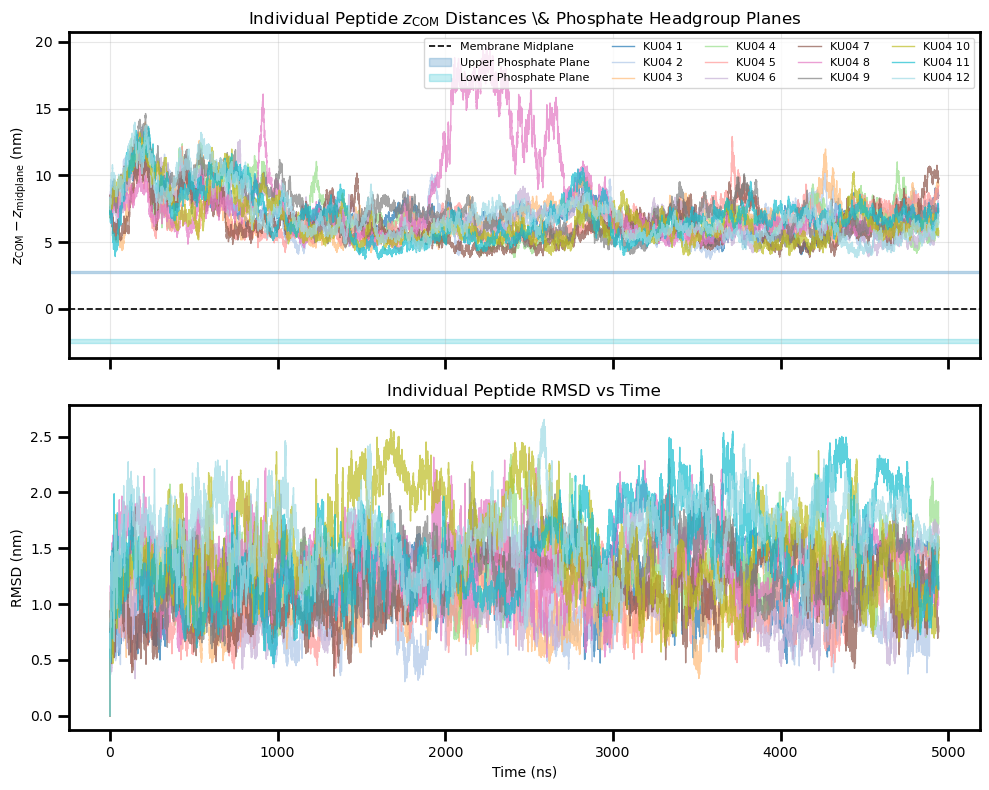

In [9]:
# ==========================================
# 5. CONVERT TO NANOMETERS & DATAFRAMES
# ==========================================

# Convert MDAnalysis Angstroms -> Nanometers (divide by 10)
z_peps_nm = z_peps_all / 10.0
z_mids_nm = z_mids_all / 10.0
z_pup_nm  = z_pup_all  / 10.0
z_plow_nm = z_plow_all / 10.0

# Calculate relative z-distances (nm)
# Distances from upper phosphate plane, lower phosphate plane, and midplane
dz_mid_nm   = z_peps_nm - z_mids_nm[:, np.newaxis]
dz_upper_nm = z_peps_nm - z_pup_nm[:, np.newaxis]
dz_lower_nm = z_peps_nm - z_plow_nm[:, np.newaxis]

# Create DataFrames
pep_cols = [f"Peptide_{i+1}" for i in range(num_peptides)]

df_dz_mid = pd.DataFrame(dz_mid_nm, columns=pep_cols)
df_dz_mid.insert(0, "Time_ns", times)
df_dz_mid.to_csv("individual_peptide_z_midplane.csv", index=False)

df_dz_upper = pd.DataFrame(dz_upper_nm, columns=pep_cols)
df_dz_upper.insert(0, "Time_ns", times)
df_dz_upper.to_csv("individual_peptide_z_upper_phosphate.csv", index=False)

print("Saved CSV outputs to current working directory.")


# ==========================================
# 6. PUBLICATION-QUALITY PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, tight_layout=True)

# --- Plot 1: Peptide z-COM relative to Phosphate Planes ---
ax1.axhline(0, color="black", linestyle="--", linewidth=1.2, label="Membrane Midplane")

# Plot upper and lower phosphate plane bands
avg_pup = (z_pup_nm - z_mids_nm).mean()
std_pup = (z_pup_nm - z_mids_nm).std()
avg_plow = (z_plow_nm - z_mids_nm).mean()
std_plow = (z_plow_nm - z_mids_nm).std()

ax1.axhspan(avg_pup - std_pup, avg_pup + std_pup, color="tab:blue", alpha=0.25, label="Upper Phosphate Plane")
ax1.axhspan(avg_plow - std_plow, avg_plow + std_plow, color="tab:cyan", alpha=0.25, label="Lower Phosphate Plane")

colors = plt.cm.tab20(np.linspace(0, 1, num_peptides))
for i in range(num_peptides):
    ax1.plot(times, dz_mid_nm[:, i], label=f"KU04 {i+1}", alpha=0.7, color=colors[i], lw=1.0)

ax1.set_ylabel(r"$z_{\mathrm{COM}} - z_{\mathrm{midplane}}$ (nm)")
ax1.set_title(r"Individual Peptide $z_{\mathrm{COM}}$ Distances \& Phosphate Headgroup Planes")
ax1.legend(ncol=5, loc="upper right", fontsize=8, frameon=True)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Individual Peptide RMSD ---
for i in range(num_peptides):
    ax2.plot(times, rmsd_nm[:, i], label=f"KU04 {i+1}", alpha=0.7, color=colors[i], lw=1.0)

ax2.set_xlabel("Time (ns)")
ax2.set_ylabel("RMSD (nm)")
ax2.set_title("Individual Peptide RMSD vs Time")
#ax2.legend(ncol=4, loc="upper right", fontsize=8, frameon=True)

for ax in [ax1, ax2]:
    # Lengthen and thicken all major ticks
    ax.tick_params(axis='both', which='major', length=8, width=2)
    # thicken the figure border lines
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        # Color them black
        spine.set_edgecolor('black')
    ax.minorticks_off()

#plt.savefig("individual_peptides_zcom_and_rmsd.svg", dpi=300)
plt.show()

## Comparative z-COM / RMSD datasets (multipeptide vs single peptide)
Generate harmonized datasets and a 2×2 comparison figure:
- Left column: multipeptide
- Right column: single peptide
- Top row: z-COM relative to membrane midplane
- Bottom row: RMSD

RMSD (single_peptide):   0%|          | 0/9 [00:00<?, ?it/s]

z-COM (single_peptide):   0%|          | 0/9 [00:00<?, ?it/s]

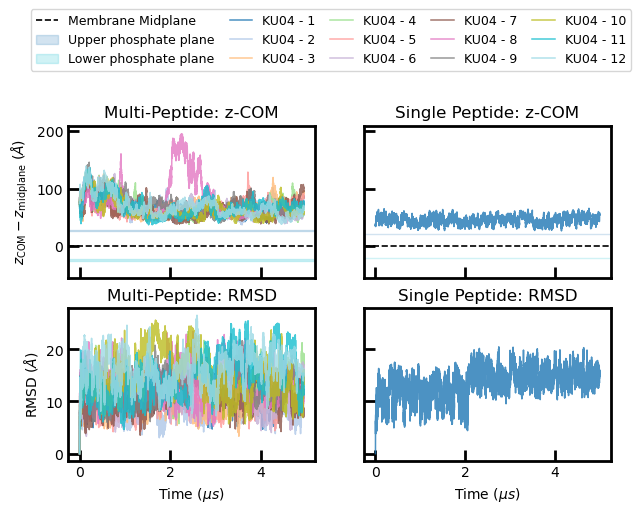

In [12]:
def compute_peptide_metrics(system_key, n_jobs_local=None):
    """Compute peptide z-COM (relative to midplane) and RMSD in nm for a system."""
    cfg = complexes[system_key]
    top_f = cfg["top_file"]
    traj_f = cfg["traj_file"]

    if n_jobs_local is None:
        n_jobs_local = min(8, cpu_count())

    u_sys = mda.Universe(top_f, traj_f)
    n_frames_sys = len(u_sys.trajectory)
    times_sys = np.array([ts.time / 1000.0 for ts in u_sys.trajectory])  # ps -> ns

    protein_sys = u_sys.select_atoms(pep_sel)
    peptides_sys = protein_sys.fragments
    num_peptides_sys = len(peptides_sys)

    if num_peptides_sys == 0:
        raise ValueError(f"No peptide fragments detected for system '{system_key}'.")

    u_sys.trajectory[0]
    ref_positions_sys = [pep.positions.copy() for pep in peptides_sys]

    chunk_size_sys = max(1, n_frames_sys // n_jobs_local)
    blocks_sys = [slice(i, min(i + chunk_size_sys, n_frames_sys)) for i in range(0, n_frames_sys, chunk_size_sys)]

    run_rmsd = partial(
        analyze_peptide_rmsd_block,
        top_f=top_f,
        traj_f=traj_f,
        p_sel=pep_sel,
        ref_pos_list=ref_positions_sys,
    )
    with Pool(n_jobs_local) as pool:
        rmsd_results_sys = list(tqdm(pool.imap(run_rmsd, blocks_sys), total=len(blocks_sys), desc=f"RMSD ({system_key})"))

    rmsd_nm_sys = np.vstack(rmsd_results_sys) / 10.0

    run_z = partial(
        analyze_peptide_z_block,
        top_f=top_f,
        traj_f=traj_f,
        p_sel=pep_sel,
        m_sel=memb_sel,
        ph_sel=phos_sel,
    )
    with Pool(n_jobs_local) as pool:
        z_results_sys = list(tqdm(pool.imap(run_z, blocks_sys), total=len(blocks_sys), desc=f"z-COM ({system_key})"))

    z_peps_nm_sys = np.vstack([r[0] for r in z_results_sys]) / 10.0
    z_mids_nm_sys = np.concatenate([r[1] for r in z_results_sys]) / 10.0
    z_pup_nm_sys = np.concatenate([r[2] for r in z_results_sys]) / 10.0
    z_plow_nm_sys = np.concatenate([r[3] for r in z_results_sys]) / 10.0
    dz_mid_nm_sys = z_peps_nm_sys - z_mids_nm_sys[:, np.newaxis]

    return {
        "name": system_key,
        "times_ns": times_sys,
        "num_peptides": num_peptides_sys,
        "rmsd_nm": rmsd_nm_sys,
        "dz_mid_nm": dz_mid_nm_sys,
        "z_pup_rel_nm": z_pup_nm_sys - z_mids_nm_sys,
        "z_plow_rel_nm": z_plow_nm_sys - z_mids_nm_sys,
    }


# Reuse existing multipeptide arrays if already available; otherwise compute them here
try:
    metrics_multi = {
        "name": "multipeptide",
        "times_ns": times,
        "num_peptides": num_peptides,
        "rmsd_nm": rmsd_nm,
        "dz_mid_nm": dz_mid_nm,
        "z_pup_rel_nm": z_pup_nm - z_mids_nm,
        "z_plow_rel_nm": z_plow_nm - z_mids_nm,
    }
except NameError:
    metrics_multi = compute_peptide_metrics("multipeptide", n_jobs_local=n_jobs)

metrics_single = compute_peptide_metrics("single_peptide", n_jobs_local=n_jobs)


# Save harmonized outputs for downstream analysis
for metrics in [metrics_multi, metrics_single]:
    system = metrics["name"]
    t = metrics["times_ns"]

    pep_cols_local = [f"Peptide_{i+1}" for i in range(metrics["num_peptides"])]

    df_z_local = pd.DataFrame(metrics["dz_mid_nm"], columns=pep_cols_local)
    df_z_local.insert(0, "Time_ns", t)
    df_z_local.to_csv(f"{system}_zcom_midplane_nm.csv", index=False)

    df_r_local = pd.DataFrame(metrics["rmsd_nm"], columns=pep_cols_local)
    df_r_local.insert(0, "Time_ns", t)
    df_r_local.to_csv(f"{system}_rmsd_nm.csv", index=False)


# 2x2 publication-style comparison: columns = systems, rows = metrics
fig, axs = plt.subplots(2, 2, figsize=(7, 5), sharex="col", sharey="row")
fig.subplots_adjust(top=0.78)  # reserve room for global legend above titles

legend_handles = None
legend_labels = None

for col, metrics in enumerate([metrics_multi, metrics_single]):
    t = metrics["times_ns"]/ 1000  # Convert ns -> µs for plotting
    dz = metrics["dz_mid_nm"] * 10 # Convert nm -> Å for plotting
    rmsd_vals = metrics["rmsd_nm"] * 10 # Convert nm -> Å for plotting
    npep = metrics["num_peptides"]

    colors_local = plt.cm.tab20(np.linspace(0, 1, max(2, npep)))

    # Row 1: z-COM relative to membrane midplane
    ax_top = axs[0, col]
    ax_top.axhline(0, color="black", linestyle="--", linewidth=1.2, label="Membrane Midplane")

    pup_rel = metrics["z_pup_rel_nm"] * 10 # Convert nm -> Å for plotting
    plow_rel = metrics["z_plow_rel_nm"] * 10 # Convert nm -> Å for plotting
    ax_top.axhspan(pup_rel.mean() - pup_rel.std(), pup_rel.mean() + pup_rel.std(), color="tab:blue", alpha=0.20, label="Upper phosphate plane")
    ax_top.axhspan(plow_rel.mean() - plow_rel.std(), plow_rel.mean() + plow_rel.std(), color="tab:cyan", alpha=0.20, label="Lower phosphate plane")

    for i in range(npep):
        ax_top.plot(t, dz[:, i], lw=1.1, alpha=0.8, color=colors_local[i], label=f"KU04 - {i+1}")
        ax_top.set_ylim(-55, 210)

    if col == 0:
        ax_top.set_ylabel(r"$z_{\mathrm{COM}} - z_{\mathrm{midplane}}$ ($\AA$)")
        legend_handles, legend_labels = ax_top.get_legend_handles_labels()

    title_left = "Multi-Peptide" if metrics["name"] == "multipeptide" else "Single Peptide"
    ax_top.set_title(f"{title_left}: z-COM")

    # Row 2: RMSD
    ax_bot = axs[1, col]
    for i in range(npep):
        ax_bot.plot(t, rmsd_vals[:, i], lw=1.1, alpha=0.8, color=colors_local[i])

    if col == 0:
        ax_bot.set_ylabel(r"RMSD ($\AA$)")
    ax_bot.set_title(f"{title_left}: RMSD")
    ax_bot.set_xlabel(r"Time ($\mu s$)")

# Figure-level legend above both columns (3 rows x 5 columns)
if legend_handles and legend_labels:
    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=5,
        fontsize=9,
        frameon=True,
        columnspacing=1.2,
        handlelength=1.8,
        borderaxespad=0.3,
    )

for ax in axs.ravel():
    ax.tick_params(axis="both", which="major", length=8, width=2, direction="in")
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor("black")
    ax.minorticks_off()

plt.savefig("ku04amp01_multipeptide_vs_single_2x2_zcom_rmsd.svg", dpi=300)
plt.show()

Nope. No evidence of translocation at all. Not even with multiple peptides.

Now, checking for contacts with prolint

In [55]:
from prolint import Universe, setup_logging
import logging

# Enable logging to see progress
setup_logging(level=logging.INFO)

# Load simulation
universe = Universe(top_file, traj_file)

# Check what was loaded
print(f"Trajectory: {universe.trajectory.n_frames} frames")
print(f"Query atoms: {universe.query.n_atoms} (protein)")
print(f"Database atoms: {universe.database.n_atoms} (non-protein)")

2026-08-04 19:51:01,058 - prolint.core.universe - INFO - Loading topology: simulation_cg_multipeptide/traj_dry.tpr
2026-08-04 19:51:01,059 - prolint.core.universe - INFO - Loading trajectory: simulation_cg_multipeptide/traj_dry.xtc
2026-08-04 19:51:01,358 - prolint.core.universe - INFO - Query selection: 'protein' (984 atoms)
2026-08-04 19:51:01,369 - prolint.core.universe - INFO - Database selection: 'not protein' (6073 atoms)
2026-08-04 19:51:01,391 - prolint.core.universe - INFO - Universe loaded: 24714 frames, 7057 atoms, 928 residues


Trajectory: 24714 frames
Query atoms: 984 (protein)
Database atoms: 6073 (non-protein)


Since there are 12 replicas of the peptide here:

In [56]:
from prolint.core.replica_detection import detect_replicas

# Check for replicas in your system
result = detect_replicas(universe.query)
print(f"Found {result.n_replicas} replicas")
for info in result.replica_info:
    print(f"  Replica {info.replica_id}: {info.n_residues} residues")

2026-08-04 19:51:06,586 - prolint.core.replica_detection - INFO - Detected 12 replicas by bond connectivity


Found 12 replicas
  Replica A: 36 residues
  Replica B: 36 residues
  Replica C: 36 residues
  Replica D: 36 residues
  Replica E: 36 residues
  Replica F: 36 residues
  Replica G: 36 residues
  Replica H: 36 residues
  Replica I: 36 residues
  Replica J: 36 residues
  Replica K: 36 residues
  Replica L: 36 residues


In [57]:
# Analyze only the phosphates of lipids in a membrane model
universe.database = universe.select_atoms(phos_sel)

print("Computing contacts for all peptides")
contacts_allp = universe.compute_contacts(cutoff=7.0)
# Run analysis
result_allp = contacts_allp.analyze("timeseries")


2026-08-04 19:51:14,596 - prolint.core.replica_detection - INFO - Detected 12 replicas by bond connectivity
2026-08-04 19:51:14,598 - prolint.core.universe - INFO - Analyzing 12 replicas with unique residue IDs
2026-08-04 19:51:14,615 - prolint.computers.contacts - INFO - Computing contacts: cutoff=7.0 Å, frames=24714


Computing contacts for all peptides


  0%|          | 0/24714 [00:00<?, ?it/s]

2026-08-04 19:51:23,073 - prolint.computers.contacts - INFO - Frame progress: 2472/24714 (10%)
2026-08-04 19:51:31,974 - prolint.computers.contacts - INFO - Frame progress: 4943/24714 (20%)
2026-08-04 19:51:40,883 - prolint.computers.contacts - INFO - Frame progress: 7415/24714 (30%)
2026-08-04 19:51:50,073 - prolint.computers.contacts - INFO - Frame progress: 9886/24714 (40%)
2026-08-04 19:52:00,247 - prolint.computers.contacts - INFO - Frame progress: 12357/24714 (50%)
2026-08-04 19:52:11,257 - prolint.computers.contacts - INFO - Frame progress: 14829/24714 (60%)
2026-08-04 19:52:20,811 - prolint.computers.contacts - INFO - Frame progress: 17300/24714 (70%)
2026-08-04 19:52:29,994 - prolint.computers.contacts - INFO - Frame progress: 19772/24714 (80%)
2026-08-04 19:52:40,051 - prolint.computers.contacts - INFO - Frame progress: 22243/24714 (90%)
2026-08-04 19:52:50,952 - prolint.computers.contacts - INFO - Frame progress: 24714/24714 (100%)
2026-08-04 19:52:50,961 - prolint.computers

In [58]:
times_mus = np.array([ts.time/1e6 for ts in universe.trajectory])

In [59]:
times_mus[-1]

4.9426

visualize where phosphate headgroup molecules (database) preferentially locate around the peptides.

The peptide (query)

Computes the 2D spatial distribution of database molecule positions relative to the query center of mass (in red) over trajectory frames.

In [60]:
# Compute 2D density map
result_rhomap = contacts_allp.analyze(
    "density_map",
    bins=50,                      # Resolution
    frame_start=0,
    frame_end=None,               # All frames
    frame_step=1
)

2026-08-04 19:53:47,911 - prolint.analysis.density - INFO - Computing density map: 24714 frames, 50 bins


### Single Peptide-membrane

In [62]:
sp_topol_file = "simulation_cg_trans_2.4nm/traj_dry.tpr"
sp_traj_file = "simulation_cg_trans_2.4nm/traj_dry.xtc"


# Load simulation
u_sp = Universe(sp_topol_file, sp_traj_file)

# Check what was loaded
print(f"Trajectory: {u_sp.trajectory.n_frames} frames")
print(f"Query atoms: {u_sp.query.n_atoms} (protein)")
print(f"Database atoms: {u_sp.database.n_atoms} (non-protein)")

2026-08-04 19:55:29,804 - prolint.core.universe - INFO - Loading topology: simulation_cg_trans_2.4nm/traj_dry.tpr
2026-08-04 19:55:29,805 - prolint.core.universe - INFO - Loading trajectory: simulation_cg_trans_2.4nm/traj_dry.xtc
2026-08-04 19:55:29,961 - prolint.core.universe - INFO - Query selection: 'protein' (82 atoms)
2026-08-04 19:55:29,962 - prolint.core.universe - INFO - Database selection: 'not protein' (7749 atoms)
2026-08-04 19:55:29,986 - prolint.core.universe - INFO - Universe loaded: 25001 frames, 7831 atoms, 668 residues


Trajectory: 25001 frames
Query atoms: 82 (protein)
Database atoms: 7749 (non-protein)


In [63]:
# Analyze only the phosphates of lipids in a membrane model
u_sp.database = u_sp.select_atoms(phos_sel)

print("Computing contacts for all peptides")
contacts_sp = u_sp.compute_contacts(cutoff=7.0)
# Run analysis


2026-08-04 19:55:35,393 - prolint.computers.contacts - INFO - Computing contacts: cutoff=7.0 Å, frames=25001


Computing contacts for all peptides


  0%|          | 0/25001 [00:00<?, ?it/s]

2026-08-04 19:55:38,904 - prolint.computers.contacts - INFO - Frame progress: 2501/25001 (10%)
2026-08-04 19:55:42,300 - prolint.computers.contacts - INFO - Frame progress: 5001/25001 (20%)
2026-08-04 19:55:45,791 - prolint.computers.contacts - INFO - Frame progress: 7501/25001 (30%)
2026-08-04 19:55:49,305 - prolint.computers.contacts - INFO - Frame progress: 10001/25001 (40%)
2026-08-04 19:55:52,754 - prolint.computers.contacts - INFO - Frame progress: 12501/25001 (50%)
2026-08-04 19:55:56,318 - prolint.computers.contacts - INFO - Frame progress: 15001/25001 (60%)
2026-08-04 19:55:59,901 - prolint.computers.contacts - INFO - Frame progress: 17501/25001 (70%)
2026-08-04 19:56:03,514 - prolint.computers.contacts - INFO - Frame progress: 20001/25001 (80%)
2026-08-04 19:56:07,034 - prolint.computers.contacts - INFO - Frame progress: 22501/25001 (90%)
2026-08-04 19:56:10,603 - prolint.computers.contacts - INFO - Frame progress: 25001/25001 (100%)
2026-08-04 19:56:10,606 - prolint.computer

In [64]:
# Compute 2D density map
result_rhomap_sp = contacts_sp.analyze(
    "density_map",
    bins=50,                      # Resolution
    frame_start=0,
    frame_end=None,               # All frames
    frame_step=1
)

2026-08-04 19:56:15,664 - prolint.analysis.density - INFO - Computing density map: 25001 frames, 50 bins


### Membrane-only control (no peptide): pseudo-query phosphate density map
To make a fair comparison with prolint query-centered density maps, the no-peptide control is built as a **pseudo-query** map.

Method summary:
- Use the membrane phosphate COM as a per-frame reference (pseudo-query center).
- Compute phosphate coordinates relative to that reference in XY.
- Apply minimum-image periodic boundary correction.
- Build a 2D density map in the same XY window and binning scheme used for peptide-centered analysis.

This gives an apples-to-apples control for testing whether multipeptide undulations exceed baseline membrane fluctuations.

In [65]:
nopep_topol_file = complexes["nopeptide"]["top_file"]
nopep_traj_file = complexes["nopeptide"]["traj_file"]

u_np = mda.Universe(nopep_topol_file, nopep_traj_file)
phos_np = u_np.select_atoms(phos_sel)

# Pseudo-query control map:
# Use membrane phosphate COM as a per-frame reference and compute
# phosphate positions relative to that reference with minimum-image PBC correction.
frame_step_np = 1
bins_ctrl = 50
xy_window = 60.0  # Angstrom; symmetric window around pseudo-query reference

dxy_all = []
for ts in tqdm(u_np.trajectory[::frame_step_np], desc="No-peptide pseudo-query density"):
    box_xy = ts.dimensions[:2].astype(float)
    ref_xy = phos_np.center_of_mass(unwrap=False)[:2]
    pos_xy = phos_np.positions[:, :2]

    dxy = pos_xy - ref_xy
    # Minimum-image convention in XY
    dxy[:, 0] -= box_xy[0] * np.round(dxy[:, 0] / box_xy[0])
    dxy[:, 1] -= box_xy[1] * np.round(dxy[:, 1] / box_xy[1])

    dxy_all.append(dxy)

dxy_all = np.vstack(dxy_all)

H_np, xedges_np, yedges_np = np.histogram2d(
    dxy_all[:, 0],
    dxy_all[:, 1],
    bins=bins_ctrl,
    range=[[-xy_window, xy_window], [-xy_window, xy_window]],
    density=True,
)

# Transpose to match imshow row/column orientation
nopeptide_density_map = {
    "H": H_np.T,
    "xedges": xedges_np,
    "yedges": yedges_np,
}

print(f"Pseudo-query control density grid shape: {nopeptide_density_map['H'].shape}")

No-peptide pseudo-query density:   0%|          | 0/25001 [00:00<?, ?it/s]

Pseudo-query control density grid shape: (50, 50)


### Plot all results

### Methods note (control map comparability)
For rigorous comparison to prolint query-centered density maps, the membrane-only control is plotted as a **pseudo-query** density map:

- Per frame, phosphate positions are referenced to the phosphate COM.
- XY displacements are corrected with minimum-image PBC wrapping.
- Control and peptide-conditioned maps use matched XY binning/window and a shared linear color scale.

Interpretation focus: spatial undulation patterns that are present in multipeptide maps but absent in control are consistent with peptide-associated membrane perturbation under this analysis framework.

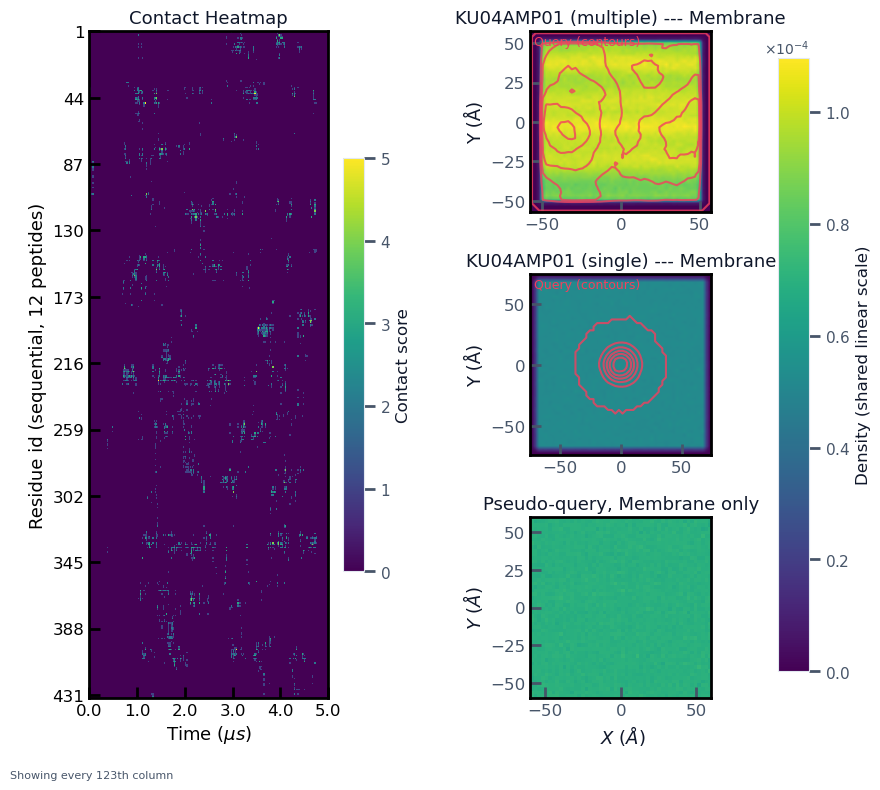

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from prolint.plotting import plot
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize

fig = plt.figure(figsize=(9, 8))
gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1], width_ratios=[1, 1])

# Left column: contact heatmap
ax0 = fig.add_subplot(gs[0:3, 0])
plot("heatmap", result_allp, colorscheme="viridis", ax=ax0)

img0 = ax0.images[0]
data = img0.get_array()

target_max_us = 5.0
n_cols = data.shape[1]

# Map the heatmap columns to the actual time points
if len(times_mus) >= n_cols:
    frame_idx = np.linspace(0, len(times_mus) - 1, n_cols).round().astype(int)
    mapped_times = times_mus[frame_idx]
else:
    mapped_times = np.linspace(0, times_mus[-1], n_cols)

# Add only a small zero-padding region at the end
pad_len = max(1, int(0.05 * n_cols))  # ~5% of width
padded_data = np.pad(data, ((0, 0), (0, pad_len)), mode="constant", constant_values=0)

img0.set_data(padded_data)
img0.set_extent([0, target_max_us, padded_data.shape[0], 0])

ax0.set_xlim(0, target_max_us)
tick_positions = np.linspace(0, target_max_us, 6)
ax0.set_xticks(tick_positions)
ax0.set_xticklabels([f"{t:.1f}" for t in tick_positions])

ax0.set_xlabel(r"Time ($\mu s$)", fontsize=13)
ax0.set_ylabel("Residue id (sequential, 12 peptides)", fontsize=13)
ax0.set_title("Contact Heatmap", fontsize=13)

cbar0 = fig.colorbar(img0, ax=ax0, shrink=0.62)
cbar0.ax.tick_params(labelsize=11)
cbar0.set_label("Contact score", fontsize=12)


# Right column: peptide-conditioned density maps (prolint)
ax1 = fig.add_subplot(gs[0, 1])
plot(
    "density_map",
    result_rhomap,
    show_query_contours=True,
    colorscheme="viridis",
    ax=ax1,
)
ax1.set_title("KU04AMP01 (multiple) --- Membrane", fontsize=13)
ax1.set_xlabel(None)
img1 = ax1.images[0]

ax2 = fig.add_subplot(gs[1, 1])
plot(
    "density_map",
    result_rhomap_sp,
    show_query_contours=True,
    colorscheme="viridis",
    ax=ax2,
)
ax2.set_title("KU04AMP01 (single) --- Membrane", fontsize=13)
ax2.set_xlabel(None)
img2 = ax2.images[0]


# Pseudo-query control panel (no peptide): phosphate XY density relative to membrane reference
ax3 = fig.add_subplot(gs[2, 1])
H_ctrl = nopeptide_density_map["H"]
extent_ctrl = [
    nopeptide_density_map["xedges"][0],
    nopeptide_density_map["xedges"][-1],
    nopeptide_density_map["yedges"][0],
    nopeptide_density_map["yedges"][-1],
]

img3 = ax3.imshow(
    H_ctrl,
    origin="lower",
    extent=extent_ctrl,
    cmap="viridis",
    aspect="equal",
)
ax3.set_xlim(extent_ctrl[0], extent_ctrl[1])
ax3.set_ylim(extent_ctrl[2], extent_ctrl[3])
ax3.set_aspect("equal", adjustable="box")
ax3.set_title("Pseudo-query, Membrane only", fontsize=13)
ax3.set_xlabel(r" $X$ ($\AA$)")
ax3.set_ylabel(r"$Y$ ($\AA$)")

# Shared linear density scaling for fair visual comparison across right-column panels
density_arrays = [
    np.asarray(np.ma.filled(img1.get_array(), np.nan), dtype=float),
    np.asarray(np.ma.filled(img2.get_array(), np.nan), dtype=float),
    np.asarray(np.ma.filled(img3.get_array(), np.nan), dtype=float),
]
finite_values = np.concatenate([arr[np.isfinite(arr)] for arr in density_arrays])
shared_vmin = float(np.nanmin(finite_values))
shared_vmax = float(np.nanmax(finite_values))
if np.isclose(shared_vmin, shared_vmax):
    shared_vmax = shared_vmin + 1e-12
shared_norm = Normalize(vmin=shared_vmin, vmax=shared_vmax)
for _img in (img1, img2, img3):
    _img.set_norm(shared_norm)

# Single shared colorbar for all right-column density maps
cbar_density = fig.colorbar(img3, ax=[ax1, ax2, ax3], shrink=0.92)
cbar_density.ax.tick_params(labelsize=11)
cbar_density.set_label("Density (shared linear scale)", fontsize=12)

# Final geometry lock: match control panel box width/height to the panel above
fig.canvas.draw()
pos2 = ax2.get_position()
pos3 = ax3.get_position()
ax3.set_position([pos2.x0, pos3.y0, pos2.width, pos2.height])

for ax in [ax0, ax1, ax2, ax3]:
    ax.xaxis.label.set_size(13)
    ax.yaxis.label.set_size(13)
    ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=12, direction="in")
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor("black")
    ax.minorticks_off()

# Remove only the extra axes created by the plotting helpers
for extra_ax in list(fig.axes):
    if extra_ax not in {ax0, ax1, ax2, ax3, cbar0.ax, cbar_density.ax}:
        fig.delaxes(extra_ax)

from matplotlib.ticker import ScalarFormatter

for cbar in [cbar0, cbar_density]:
    cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    cbar.ax.yaxis.get_major_formatter().set_scientific(True)
    cbar.ax.yaxis.get_major_formatter().set_powerlimits((0, 0))
    cbar.ax.tick_params(which="major", length=8, width=2)
    cbar.ax.minorticks_off()

fig.savefig("ku04amp-multi-membrane-bilayer-cg-PP.svg", dpi=300)
plt.show()

Using a pseudo-query control (membrane-only, PBC-corrected, query-relative frame), the density comparison is now methodologically consistent with the prolint peptide-centered maps.

### Updated interpretation
- The strong undulating/non-uniform pattern in the **multipeptide** density map is not reproduced in the pseudo-query control.
- The control remains comparatively smoother, indicating those multipeptide features are unlikely to be a coordinate-origin or normalization artifact.
- With shared linear scaling and matched reference framing, this supports **peptide-induced membrane perturbation/disruption** in the multipeptide condition.

### Important scope note
This supports membrane disruption over the simulated timescale, but does not by itself prove full translocation.

Reference: https://prolint2.readthedocs.io/en/latest/tutorials/analysis-types.html

## Area per lipid


See: https://lipyphilic.readthedocs.io/en/latest/reference/analyses.html


First, run a leaflet analysis:


In [67]:
import MDAnalysis as mda
import lipyphilic as lpp

frame_skip = 50
complexes['multipeptide']
# Load an MDAnalysis Universe
top_file = complexes['multipeptide']['top_file']
traj_file = complexes['multipeptide']['traj_file']
u = mda.Universe(top_file, traj_file)

# Find which leaflet each lipid is in at each frame
leaflets = lpp.AssignLeaflets(
  universe=u,
  lipid_sel=phos_sel
  )

# Select which frames to use and perform the analysis
leaflets.run(start=None, stop=None, step=frame_skip, verbose=True)  # this will use every 50th frame in the trajectory

  0%|          | 0/495 [00:00<?, ?it/s]

Then, get Area per lipid

In [68]:
areas = lpp.analysis.AreaPerLipid(
  universe=u,
  lipid_sel=phos_sel,  # assuming we're using the MARTINI forcefield
  leaflets=leaflets.leaflets
  )

areas.run(start=None, stop=None, step=frame_skip, verbose=True)  # this will use every 50th frame in the trajectory

  0%|          | 0/495 [00:00<?, ?it/s]

In [69]:
stop_time = u.trajectory[-1].time / 1000.0  # Convert ps to ns
# Create a time array for plotting
times = np.arange(0, stop_time + 1, frame_skip * u.trajectory.dt / 1000.0)  # Convert ps to ns
# Select the slice of times corresponding to the frames analyzed
print(times.shape, areas.areas.shape)

(495,) (496, 495)


In [70]:
import MDAnalysis as mda
import lipyphilic as lpp

complexes['single_peptide']
# Load an MDAnalysis Universe
top_file = complexes['single_peptide']['top_file']
traj_file = complexes['single_peptide']['traj_file']
u = mda.Universe(top_file, traj_file)

# Find which leaflet each lipid is in at each frame
leaflets_sp = lpp.AssignLeaflets(
  universe=u,
  lipid_sel=phos_sel
  )

# Select which frames to use and perform the analysis
leaflets_sp.run(start=None, stop=None, step=50, verbose=True)  # this will use every 50th frame in the trajectory

areas_sp = lpp.analysis.AreaPerLipid(
  universe=u,
  lipid_sel=phos_sel,  # assuming we're using the MARTINI forcefield
  leaflets=leaflets_sp.leaflets
  )

areas_sp.run(start=None, stop=None, step=50, verbose=True)  # this will use every 50th frame in the trajectory
stop_time = u.trajectory[-1].time / 1000.0  # Convert ps to ns
times_sp = np.arange(0, stop_time + 1, frame_skip * u.trajectory.dt / 1000.0)  # Convert ps to ns

  0%|          | 0/501 [00:00<?, ?it/s]

  0%|          | 0/501 [00:00<?, ?it/s]

In [71]:
import MDAnalysis as mda
import lipyphilic as lpp

complexes['nopeptide']
# Load an MDAnalysis Universe
top_file = complexes['nopeptide']['top_file']
traj_file = complexes['nopeptide']['traj_file']
u = mda.Universe(top_file, traj_file)

# Find which leaflet each lipid is in at each frame
leaflets_np = lpp.AssignLeaflets(
  universe=u,
  lipid_sel=phos_sel
  )

# Select which frames to use and perform the analysis
leaflets_np.run(start=None, stop=None, step=50, verbose=True)  # this will use every 50th frame in the trajectory

areas_np = lpp.analysis.AreaPerLipid(
  universe=u,
  lipid_sel=phos_sel,  # assuming we're using the MARTINI forcefield
  leaflets=leaflets_np.leaflets
  )

areas_np.run(start=None, stop=None, step=50, verbose=True)  # this will use every 50th frame in the trajectory
stop_time = u.trajectory[-1].time / 1000.0  # Convert ps to ns
times_np = np.arange(0, stop_time + 1, frame_skip * u.trajectory.dt / 1000.0)  # Convert ps to ns

  0%|          | 0/501 [00:00<?, ?it/s]

  0%|          | 0/501 [00:00<?, ?it/s]

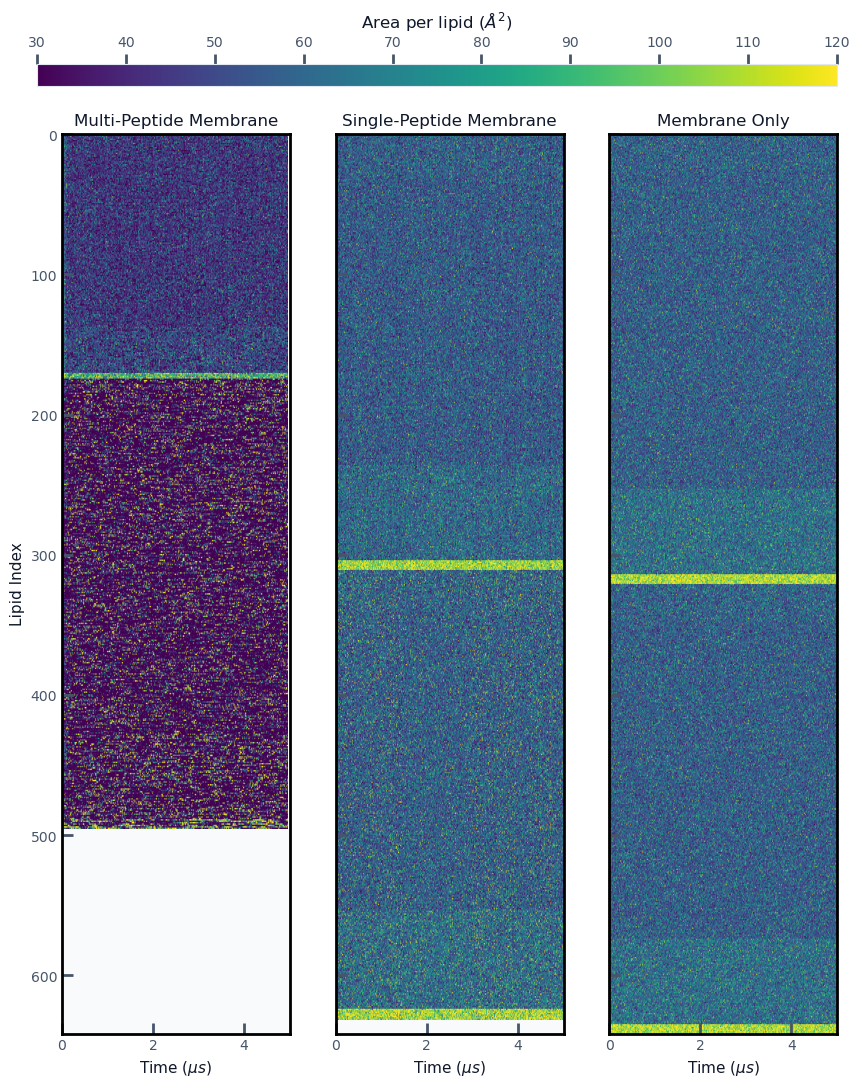

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter

# 1) Build shared normalization across all three matrices
all_vals = np.concatenate([
    np.ravel(areas.areas),
    np.ravel(areas_sp.areas),
    np.ravel(areas_np.areas),
])
all_vals = all_vals[np.isfinite(all_vals)]
#shared_norm = Normalize(vmin=all_vals.min(), vmax=all_vals.max())
shared_norm = Normalize(vmin=30, vmax=120, clip=True)  # in Å² (adjust as needed)
# 2) Create figure (avoid tight_layout=True here; we'll place things manually)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 12), sharey=True, sharex=True)
fig.subplots_adjust(top=0.86, wspace=0.20)  # leave room for suptitle + top colorbar

# 3) Plot all three with same norm
im1 = ax1.imshow(areas.areas,    aspect='auto', cmap='viridis', norm=shared_norm)
ax1.set_title("Multi-Peptide Membrane", fontsize=12)
im2 = ax2.imshow(areas_sp.areas, aspect='auto', cmap='viridis', norm=shared_norm)
ax2.set_title("Single-Peptide Membrane", fontsize=12)
im3 = ax3.imshow(areas_np.areas, aspect='auto', cmap='viridis', norm=shared_norm)
ax3.set_title("Membrane Only", fontsize=12)

for ax, area, time_arr in [(ax1, areas, times), (ax2, areas_sp, times_sp), (ax3, areas_np, times_np)]:
    ax.tick_params(axis='both', which='major', length=8, width=2, direction='in')
    xlims = ax.get_xlim()
    ax.set_xlim([0, xlims[1]])
    # The x-axis is actually the times, but given in frames. Normalize the ticks accordingly
    # Keep only ticks that are actually inside the displayed x-range
    xt = ax.get_xticks()
    xt = xt[(xt >= 0) & (xt <= ax.get_xlim()[1] + 1e-9)]
    ax.set_xticks(xt)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v/100:g}"))
    ax.set_xlabel(r"Time ($\mu s$)")
    if ax == ax1:
        ax.set_ylabel("Lipid Index")
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')


# 5) One horizontal colorbar ABOVE suptitle, spanning all 3 columns
# [left, bottom, width, height] in figure coordinates
cax = fig.add_axes([0.10, 0.9, 0.80, 0.018])
cbar = fig.colorbar(im3, cax=cax, orientation='horizontal')
cbar.set_label(r"Area per lipid ($\AA^2$)", fontsize=12, labelpad=6)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(which='major', length=7, width=2, labelsize=10)
cbar.ax.minorticks_off()
fig.savefig("ku04amp01_multipeptide_single_nopeptide_area_per_lipid.svg", dpi=300)

## What I see in your APL heatmaps

- **Multi-peptide panel (left)** shows:
  - stronger spatial heterogeneity (more speckled/high-contrast texture),
  - more frequent bright excursions (higher local APL events),
  - a broader band of elevated variability across many lipid indices.

- **Single-peptide (middle)** and **no-peptide (right)** look comparatively smoother and more uniform overall.

That pattern is **consistent with peptide-induced local packing defects / membrane perturbation**.

## Important caveats before claiming “disruption”

- The **left panel has a white lower block** (missing/invalid values), which is likely analysis/indexing/leaflet-assignment related rather than physical rupture.
- All panels show some horizontal bright bands (likely persistent specific lipids / indexing or leaflet-label artifacts).

## Bottom line

- **Yes, there is an indication** of stronger membrane perturbation with multiple peptides, but very weak.


# Additional (Structural) Metrics 

* Lipid Order Parameter (\(S_{CD}\)) (low priority): Calculated via gmx order to check the alignment of acyl chain C-H bonds; lower values mean the core is becoming loose or fluid. See [https://lipyphilic.readthedocs.io/en/latest/reference/analysis/order_parameter.html]
> Not obtained yet, but reviewer might ask for it.
>

* Density Profiles.

    I'd compute number or mass density radially outwards from the peptide COM

    * water
    * phosphate beads
    * glycerol beads
    * lipid tails
    * peptide

    This single figure often tells an entire story:

  1. membrane thinning
  2. insertion depth
  3. water defects
  4. leaflet asymmetry

Given your specific hypothesis (PGL-PEA getting disrupted by the peptide), I would prioritize radial density profiles over 2D maps.

Compute, for each lipid species,

ρ(r)

or equivalently the radial distribution function g(r) of headgroup beads around the peptide COM.

For each species (POPG, POPE, DVPE, DOPE, TOCL), you'd get one curve.

If previous simulations are correct, the PG and PE curves should show a depletion near r=0, whereas unaffected species would approach the bulk density more quickly. This is much easier to compare quantitatively than interpreting color maps, and it's straightforward to add confidence intervals from block averaging.

In [40]:
from prolint import Universe
from tqdm.notebook import tqdm
from prolint.core.replica_detection import detect_replicas

top_file = complexes['multipeptide']['top_file']
traj_file = complexes['multipeptide']['traj_file']
n_bins=200
u = Universe(top_file, traj_file)
# Check for replicas in your system
replicas = detect_replicas(u.query)
print(f"Found {replicas.n_replicas} replicas")
for info in replicas.replica_info:
    print(f"  Replica {info.replica_id}: {info.n_residues} residues")


Found 12 replicas
  Replica A: 36 residues
  Replica B: 36 residues
  Replica C: 36 residues
  Replica D: 36 residues
  Replica E: 36 residues
  Replica F: 36 residues
  Replica G: 36 residues
  Replica H: 36 residues
  Replica I: 36 residues
  Replica J: 36 residues
  Replica K: 36 residues
  Replica L: 36 residues


In [41]:
lipid_residues = ["DVPE", "POPG", "POPE", "DOPE", "TOCL"]

peptide_replica_choice = "A"
radial_densities_dict = {}

for info in tqdm(replicas.replica_info):
    radial_densities_dict[info.replica_id] = {}
    print(f"Replica {info.replica_id}: {info.n_residues} residues")

    for lipid in lipid_residues:
        u.database = u.select_atoms(f"(resname {lipid}) and (name PO4 PO41 PO42)")
        contacts = u.compute_contacts(cutoff=7.0, verbose=False, replica=info.replica_id)
        density_result = contacts.analyze("density_map", bins=n_bins)
        result = contacts.analyze(
        "radial_density",
        density=density_result.data["density"],
        x_edges=density_result.data["x_edges"],
        y_edges=density_result.data["y_edges"],
        n_bins=n_bins
    )
        radial_densities_dict[info.replica_id][lipid] = result

  0%|          | 0/12 [00:00<?, ?it/s]

Replica A: 36 residues


  0%|          | 0/24714 [00:00<?, ?it/s]

  0%|          | 0/24714 [00:00<?, ?it/s]

  0%|          | 0/24714 [00:00<?, ?it/s]

...

  0%|          | 0/24714 [00:00<?, ?it/s]

  0%|          | 0/24714 [00:00<?, ?it/s]

  0%|          | 0/24714 [00:00<?, ?it/s]

  0%|          | 0/24714 [00:00<?, ?it/s]

  0%|          | 0/24714 [00:00<?, ?it/s]

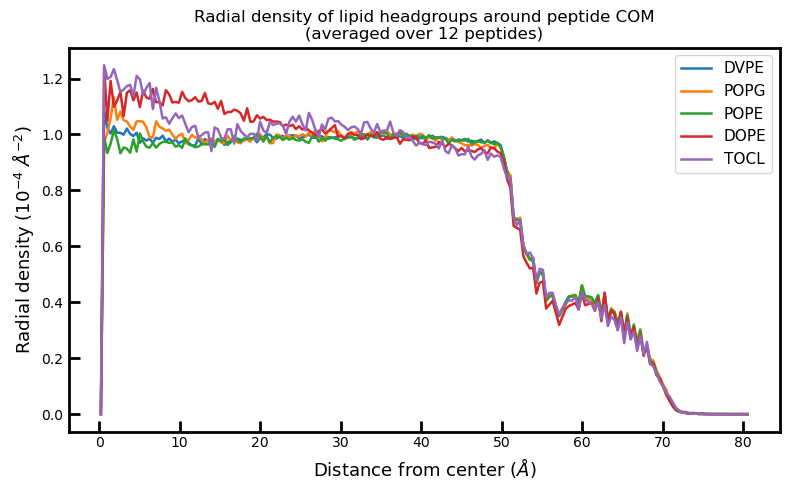

In [44]:
# Average radial density over all replicas for each lipid
avg_radial_densities = {}
for lipid in lipid_residues:
    stacked = np.array([
        radial_densities_dict[info.replica_id][lipid].data["radial_density"]
        for info in replicas.replica_info
    ])
    avg_radial_densities[lipid] = stacked.mean(axis=0)

# Use r_centers from any replica/lipid as shared x-axis
r_centers = np.array(radial_densities_dict[replicas.replica_info[0].replica_id][lipid_residues[0]].data["r_centers"])

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for lipid in lipid_residues:
    ax.plot(r_centers, avg_radial_densities[lipid]*1e4, label=lipid, lw=1.8)

ax.set_xlabel(r"Distance from center ($\AA$)", fontsize=13)
ax.set_ylabel(r"Radial density ($10^{-4}\;\AA^{-2}$)", fontsize=13)
ax.set_title("Radial density of lipid headgroups around peptide COM\n(averaged over 12 peptides)", fontsize=12)
ax.legend(fontsize=11)
ax.tick_params(axis="both", which="major", length=8, width=2, direction="in")
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor("black")

ax.minorticks_off()
plt.tight_layout()
plt.savefig("radial_density_lipids_avg_peptides.svg", dpi=300)
plt.show()